In [1]:
import numpy as np
import matplotlib.pyplot as plt
from meer21cm import MockSimulation
from meer21cm.util import create_wcs_with_range,pca_clean, center_to_edges
from meer21cm.plot import plot_map
from meer21cm.fg import ForegroundSimulation
### Define beam for mocks:
from meer21cm.telescope import dish_beam_sigma
from meer21cm.telescope import weighted_convolution
from meer21cm.telescope import isotropic_beam_profile
from meer21cm.telescope import gaussian_beam

### Mock specifications:
ra_range = [125,175]
dec_range = [-10,5]
wcs, num_pix_x, num_pix_y = create_wcs_with_range(
    ra_range,
    dec_range,
    resol=[0.5, 0.5],
    buffer=[1.2, 1.2])

nu = np.linspace(800,900,80) * 1e6 # [Hz]

mock = MockSimulation(
    seed=1234,
    nu=nu,
    wproj=wcs,
    num_pix_x=num_pix_x,
    num_pix_y=num_pix_y,
    omega_hi=5e-4,
    tracer_bias_1=1.5,
    ra_range=ra_range,
    dec_range=dec_range,
    mean_amp_1='average_hi_temp',
    density='lognormal',
    downres_factor_radial = 1/2,
    downres_factor_transverse = 1/2,
    box_buffkick=[45,25,25],
)

d_dish = 13.5
sigma_beam_ch = dish_beam_sigma(d_dish, nu)
beam = np.zeros((num_pix_x,num_pix_y,len(nu)))
for i in range(len(nu)):
    beam[:,:,i] = isotropic_beam_profile(num_pix_x,num_pix_y,wcs, gaussian_beam(sigma_beam_ch[i]) )

In [2]:
# simulate HI
mock.data = mock.propagate_mock_field_to_data(mock.mock_tracer_field_1)
HI_map = mock.data
orig_hi_map = HI_map.copy()
# simulate foreground
fg = ForegroundSimulation(
    hp_nside=256,
    wproj=mock.wproj,
    num_pix_x=mock.num_pix_x,
    num_pix_y=mock.num_pix_y,
    backend="pysm",
    pysm_preset_strings=["d1", "s1", "a1", "c1"],
    coord_system="C",
)
fg_map = fg.fg_wcs_cube(mock.nu)

# convolve map with beam
w = np.ones(np.shape(HI_map))
HI_map,w = weighted_convolution(HI_map,beam,w)
fg_map,w = weighted_convolution(fg_map,beam,w)

In [3]:
# add noise (just for illustration)
sigma_N = 4e-5
noise  = np.random.normal(0,sigma_N,np.shape(fg_map))
# PCA cleaning
obs_map = fg_map + noise + HI_map
N_fg = 5
clean_map = pca_clean(obs_map,N_fg,weights=mock.W_HI,mean_center=True, return_A=False)

fg_map[mock.W_HI==0] = np.nan
clean_map[mock.W_HI==0] = np.nan
HI_map[mock.W_HI==0] = np.nan

/var/folders/g4/7xh65ljx6l17g9wztg7t6c2w0000gn/T/ipykernel_21861/1455883099.py:15: RuntimeWarning: Mean of empty slice
  plt.imshow(np.nanmean(maps[i][:,:,int(len(nu)/2):int(len(nu)/2+10)],2).T)


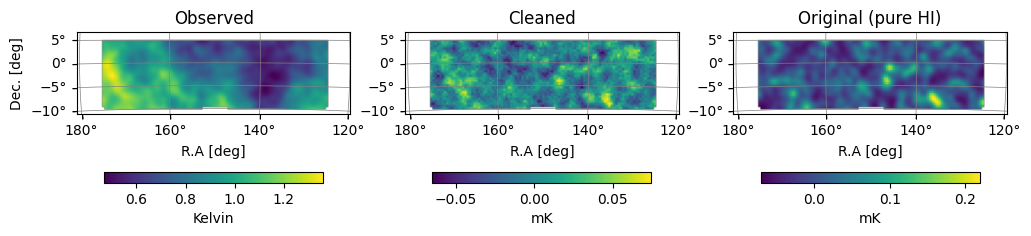

In [4]:
maps = [fg_map,1e3*clean_map,1e3*HI_map]

titles = ['Observed','Cleaned','Original (pure HI)']
cbarlabels = ['Kelvin','mK','mK']
plt.figure(figsize=(12,5))
for i in range(3):
    plt.subplot(1, 3, i+1, projection=mock.wproj)
    ax = plt.gca()
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_major_formatter('d')
    lon.set_ticks_position('b')
    lat.set_ticks_position('l')
    plt.grid(True, color='grey', ls='solid',lw=0.5)
    plt.imshow(np.nanmean(maps[i][:,:,int(len(nu)/2):int(len(nu)/2+10)],2).T)
    plt.colorbar(shrink=0.8,orientation='horizontal',label=cbarlabels[i])
    plt.xlabel('R.A [deg]')
    if i==0: plt.ylabel('Dec. [deg]')
    else: plt.ylabel('')
    plt.gca().invert_xaxis()
    plt.title(titles[i])
plt.savefig('plots/maps_Fig1.pdf',bbox_inches='tight')

In [5]:
mock_hi_field = mock.mock_tracer_field_1.copy()
x_vec_mock = tuple(list(mock.x_vec))

In [6]:
mock.data = orig_hi_map
mock.grid_scheme='tsc'
mock.downres_factor_radial = 0.5
mock.downres_factor_transverse = 0.5
himap_rg,_,_ = mock.grid_data_to_field()

In [7]:
x_vec_grid = tuple(list(mock.x_vec))

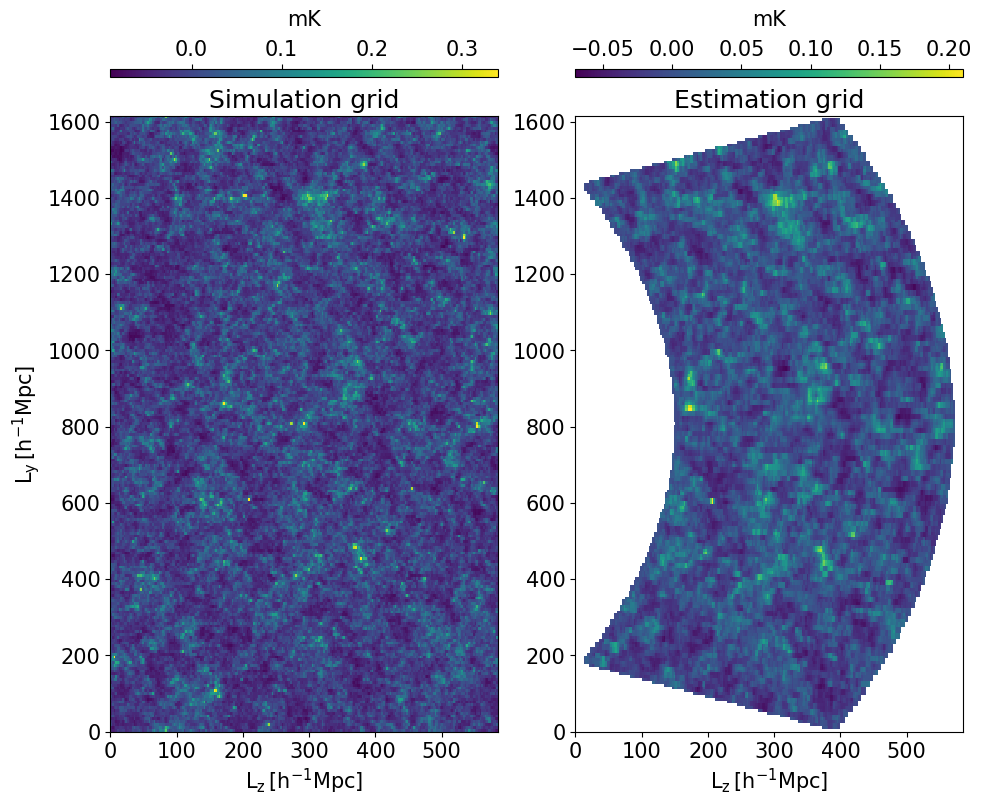

In [8]:
plt.rcParams.update({'font.size':15})
fig,axes = plt.subplots(1,2,figsize=(11,10))
arr1 = np.nanmean(mock_hi_field*1e3,0)
arr2 = np.nanmean(himap_rg*1e3,0)
arr2[(mock.counts_in_box==0).mean(0)==1] = np.nan
im = axes[0].pcolormesh(
    center_to_edges(x_vec_mock[2]) * mock.cosmo.h,
    center_to_edges(x_vec_mock[1]) * mock.cosmo.h,
    arr1,
    vmin=-0.09,
    vmax=0.34,
)
axes[0].set_ylabel(r'$\rm L_y\,[h^{-1}Mpc]$')
axes[0].set_xlabel(r'$\rm L_z\,[h^{-1}Mpc]$')
axes[0].set_rasterized(True)
cbar = plt.colorbar(im,ax=axes[0],location='top',aspect=50)
cbar.set_label('mK',y=0.0,labelpad=10)
axes[0].set_title('Simulation grid')
im = axes[1].pcolormesh(
    center_to_edges(x_vec_grid[2]) * mock.cosmo.h,
    center_to_edges(x_vec_grid[1]) * mock.cosmo.h,
    arr2,
    vmin=-0.07,
    vmax=0.21,
)
axes[1].set_xlabel(r'$\rm L_z\,[h^{-1}Mpc]$')
axes[1].set_rasterized(True)
cbar = plt.colorbar(im,ax=axes[1],location='top',aspect=50)
cbar.set_label('mK',y=0.0,labelpad=10)
axes[1].set_title('Estimation grid')
plt.savefig('plots/maps_grid.pdf',bbox_inches='tight')